In [ ]:
!pip install lifetimes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 27.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.plotting import plot_frequency_recency_matrix, plot_probability_alive_matrix
import warnings

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'online-retail-ii-uci' dataset.
Path to dataset files: /kaggle/input/online-retail-ii-uci


In [ ]:
import os
path1 = os.listdir(path)


In [ ]:
df = pd.read_csv(f'{path}/{path1[0]}')

In [ ]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df.shape

(1067371, 8)

In [ ]:
df.columns = ['InvoiceNo', 'StockCode', 'Description', 'Quantity',
              'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
print("Rows before removing cancellations:", len(df))
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print("Rows after removing cancellations:", len(df))

Rows before removing cancellations: 1067371
Rows after removing cancellations: 1047877


In [ ]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
print("Rows after removing bad quantity/price:", len(df))

Rows after removing bad quantity/price: 1041670


In [ ]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [ ]:
print("Rows before removing missing CustomerID:", len(df))
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)
print("Final clean rows:", len(df))
print("Unique customers:", df['CustomerID'].nunique())

Rows before removing missing CustomerID: 1041670
Final clean rows: 805549
Unique customers: 5878


In [ ]:
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df[['CustomerID', 'InvoiceDate', 'CohortMonth', 'InvoiceMonth']].head()

,CustomerID,InvoiceDate,CohortMonth,InvoiceMonth
0,13085,2009-12-01 07:45:00,2009-12,2009-12
1,13085,2009-12-01 07:45:00,2009-12,2009-12
2,13085,2009-12-01 07:45:00,2009-12,2009-12
3,13085,2009-12-01 07:45:00,2009-12,2009-12
4,13085,2009-12-01 07:45:00,2009-12,2009-12


Cohort Heatmap

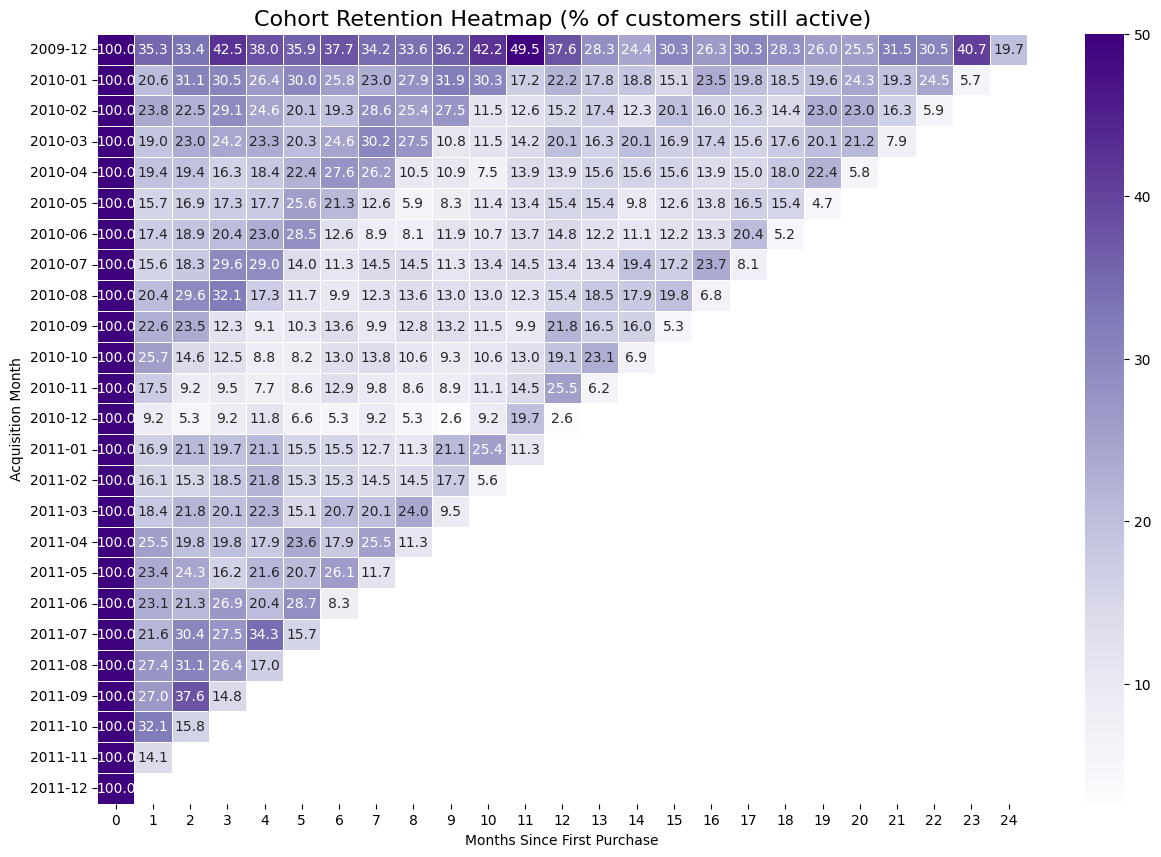

In [ ]:
cohort_data = df.groupby(['CohortMonth', 'InvoiceMonth'])\
                .agg(n_customers=('CustomerID', 'nunique')).reset_index()

cohort_data['Period'] = (cohort_data['InvoiceMonth'] - cohort_data['CohortMonth']).apply(lambda x: x.n)
cohort_pivot = cohort_data.pivot_table(index='CohortMonth', columns='Period', values='n_customers', fill_value=np.nan)

plt.figure(figsize=(15,10))
retention = cohort_pivot.divide(cohort_pivot.iloc[:,0], axis=0) * 100
sns.heatmap(retention.round(1), annot=True, fmt='.1f', cmap='Purples', linewidths=0.5, vmax=50)
plt.title('Cohort Retention Heatmap (% of customers still active)', fontsize=16)
plt.ylabel('Acquisition Month')
plt.xlabel('Months Since First Purchase')
plt.show()

In [ ]:
cohort_pivot.iloc[:5,:5]

Period,0,1,2,3,4
CohortMonth,,,,,
2009-12,955.0,337.0,319.0,406.0,363.0
2010-01,383.0,79.0,119.0,117.0,101.0
2010-02,374.0,89.0,84.0,109.0,92.0
2010-03,443.0,84.0,102.0,107.0,103.0
2010-04,294.0,57.0,57.0,48.0,54.0


In [ ]:
from lifetimes.utils import summary_data_from_transaction_data

summary = summary_data_from_transaction_data(
    df,
    customer_id_col='CustomerID',
    datetime_col='InvoiceDate',
    monetary_value_col='TotalPrice',
    observation_period_end= df['InvoiceDate'].max(),
    freq='D'
)

summary = summary[summary['monetary_value'] > 0]
print("Final customers for modeling:", len(summary))
summary.head()

Final customers for modeling: 4189


,frequency,recency,T,monetary_value
CustomerID,,,,
12346,7.0,400.0,725.0,11066.637143
12347,7.0,402.0,404.0,717.398571
12348,4.0,363.0,438.0,449.310000
12349,3.0,571.0,589.0,1120.056667
12352,8.0,356.0,392.0,338.261250


In [ ]:
bgf = BetaGeoFitter(penalizer_coef=0.0)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])

ggf = GammaGammaFitter(penalizer_coef=0.0)
ggf.fit(summary['frequency'], summary['monetary_value'])

predicted_ltv = ggf.customer_lifetime_value(
    bgf,
    summary['frequency'],
    summary['recency'],
    summary['T'],
    summary['monetary_value'],
    time=12,
    discount_rate=0.01
)

summary['Predicted_LTV_12M'] = predicted_ltv
summary = summary.sort_values('Predicted_LTV_12M', ascending=False)
summary.head(10)

,frequency,recency,T,monetary_value,Predicted_LTV_12M
CustomerID,,,,,
18102,66.0,738.0,738.0,9189.930455,239359.791615
14646,90.0,736.0,737.0,5809.905333,206415.461895
16446,1.0,205.0,205.0,168469.600000,183030.936202
17450,30.0,430.0,438.0,6924.523000,126526.170765
14156,120.0,729.0,738.0,2607.329750,123099.235867
14911,254.0,737.0,738.0,1162.358268,116314.623609
14096,16.0,97.0,101.0,4071.434375,102227.893903
13694,82.0,732.0,735.0,2365.279512,76858.351937
12415,22.0,503.0,527.0,6460.528636,74513.671344


In [ ]:
top_10_percent = summary['Predicted_LTV_12M'].quantile(0.9)

high_value_customers = summary[
    summary['Predicted_LTV_12M'] >= top_10_percent
]
t_ltv = summary['Predicted_LTV_12M'].sum()
print(f"Totol LTV of all customers = {t_ltv:.2f}")
print(f"Top 10% of customers (n={len(high_value_customers)}) will generate "
      f"£{high_value_customers['Predicted_LTV_12M'].sum():,.0f} in next 12 months")

print(f"Average predicted LTV = £{summary['Predicted_LTV_12M'].mean():.2f}")


Totol LTV of all customers = 8106571.33
Top 10% of customers (n=419) will generate £4,391,602 in next 12 months
Average predicted LTV = £1935.20


In [ ]:
summary.head()

,frequency,recency,T,monetary_value,Predicted_LTV_12M
CustomerID,,,,,
18102,66.0,738.0,738.0,9189.930455,239359.791615
14646,90.0,736.0,737.0,5809.905333,206415.461895
16446,1.0,205.0,205.0,168469.600000,183030.936202
17450,30.0,430.0,438.0,6924.523000,126526.170765
14156,120.0,729.0,738.0,2607.329750,123099.235867


In [ ]:
max_date = df['InvoiceDate'].max()
print(f"Dataset ends on: {max_date}")
target_period = 11
valid_cohorts_mask = (retention.index.to_timestamp() + pd.DateOffset(months=target_period)) <= max_date
true_month_12_retention = retention.loc[valid_cohorts_mask, target_period]
print("-" * 30)
print(f"Number of valid cohorts (actually 12+ months old): {len(true_month_12_retention)}")
print(f"Oldest cohort included: {true_month_12_retention.index.min()}")
print(f"Newest cohort included: {true_month_12_retention.index.max()}")
print("-" * 30)
print(f"Average Month-12 Retention Rate: {true_month_12_retention.mean():.2f}%")

Dataset ends on: 2011-12-09 12:50:00
------------------------------
Number of valid cohorts (actually 12+ months old): 14
Oldest cohort included: 2009-12
Newest cohort included: 2011-01
------------------------------
Average Month-12 Retention Rate: 16.41%


In [ ]:
# --- STEP 1: VERIFY RETENTION (Month 12) ---

# Re-calculate retention matrix just to be safe
cohort_sizes = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0) * 100

# We look at column index 11 because column 0 is the first month
# Index 11 = 12th Month after acquisition
m12_col_index = 11

# Get the average excluding zeros (censored data)
valid_m12_data = retention_matrix[m12_col_index]
valid_m12_data = valid_m12_data[valid_m12_data > 0] # Filter out future/empty cohorts
avg_m12_retention = valid_m12_data.mean()

# Get December specific retention
# We look for cohorts ending in '-12'
dec_cohorts = retention_matrix.index[retention_matrix.index.astype(str).str.endswith('-12')]
dec_m12_values = retention_matrix.loc[dec_cohorts, m12_col_index]

print(f"--- RETENTION REALITY CHECK ---")
print(f"Global Average Month-12 Retention: {avg_m12_retention:.2f}%")
print(f"December Cohorts Month-12 Retention:\n{dec_m12_values[dec_m12_values > 0].to_string()}")


# --- STEP 2: VERIFY LTV (December vs Rest) ---

# We need to link 'CohortMonth' to your LTV summary table
# Create a mapping of ID to Cohort
id_to_cohort = df[['CustomerID', 'CohortMonth']].drop_duplicates().set_index('CustomerID')

# Join it to your LTV summary
summary_with_cohort = summary.join(id_to_cohort)

# Create a flag for December Cohorts
summary_with_cohort['Is_Dec_Cohort'] = summary_with_cohort['CohortMonth'].astype(str).str.endswith('-12')

# Calculate LTV Stats
avg_ltv_dec = summary_with_cohort[summary_with_cohort['Is_Dec_Cohort']]['Predicted_LTV_12M'].mean()
avg_ltv_others = summary_with_cohort[~summary_with_cohort['Is_Dec_Cohort']]['Predicted_LTV_12M'].mean()

ltv_multiplier = avg_ltv_dec / avg_ltv_others

print(f"\n--- LTV REALITY CHECK ---")
print(f"Average LTV (December Cohorts): £{avg_ltv_dec:.2f}")
print(f"Average LTV (Non-Dec Cohorts):  £{avg_ltv_others:.2f}")
print(f"LTV Multiplier: {ltv_multiplier:.2f}x")

if ltv_multiplier >= 2.5 and 50 < dec_m12_values.max() < 65:
    print("\n✅ VERDICT: Your Resume statement is ACCURATE.")
else:
    print("\n⚠️ VERDICT: The numbers differ. Update your resume with the values printed above.")

--- RETENTION REALITY CHECK ---
Global Average Month-12 Retention: 16.41%
December Cohorts Month-12 Retention:
CohortMonth
2009-12    49.528796
2010-12    19.736842
Freq: M

--- LTV REALITY CHECK ---
Average LTV (December Cohorts): £3639.41
Average LTV (Non-Dec Cohorts):  £1461.58
LTV Multiplier: 2.49x

⚠️ VERDICT: The numbers differ. Update your resume with the values printed above.


In [ ]:
# --- AUGUST COHORT "RAMP UP" CHECK ---

# 1. Define the Cohort and Columns to check
# We look at '2010-08' and '2011-08'
cohorts_to_check = ['2010-08', '2011-08']

# We want to see the trend for the first 3 months (Period 1, 2, 3)
periods = [1, 2, 3]

print("--- THE AUGUST ANOMALY (Retention Increasing?) ---")

for cohort in cohorts_to_check:
    if cohort in retention.index:
        # Extract the retention rates for Month 1, 2, and 3
        rates = retention.loc[cohort, periods]

        m1 = rates[1]
        m3 = rates[3]
        growth = ((m3 - m1) / m1) * 100

        print(f"\nCohort: {cohort}")
        print(f"Month 1 Retention: {m1:.1f}%")
        print(f"Month 3 Retention: {m3:.1f}%")

        if m3 > m1:
            print(f"✅ TREND: POSITIVE (Retention GREW by {growth:.1f}%)")
        else:
            print(f"❌ TREND: Negative (Standard Churn)")

# Compare with a standard month (e.g., April)
print(f"\n--- COMPARISON (Standard Cohort: 2010-04) ---")
if '2010-04' in retention.index:
    apr_m1 = retention.loc['2010-04', 1]
    apr_m3 = retention.loc['2010-04', 3]
    print(f"Month 1: {apr_m1:.1f}% -> Month 3: {apr_m3:.1f}%")
    print(f"Result: Retention dropped (Standard behavior)")

--- THE AUGUST ANOMALY (Retention Increasing?) ---

Cohort: 2010-08
Month 1 Retention: 20.4%
Month 3 Retention: 32.1%
✅ TREND: POSITIVE (Retention GREW by 57.6%)

Cohort: 2011-08
Month 1 Retention: 27.4%
Month 3 Retention: 26.4%
❌ TREND: Negative (Standard Churn)

--- COMPARISON (Standard Cohort: 2010-04) ---
Month 1: 19.4% -> Month 3: 16.3%
Result: Retention dropped (Standard behavior)
